In [3]:
import numpy as np
import pandas as pd
import holidays
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [5]:
# Google Drive file ID from the provided link
file_id = '1t6uNkz41doMntZYNvHJvgLyD1DLbnEq4'

# Output filename
output_filename = 'mta_hourly_with_lags.csv'

# Download the file using gdown
gdown.download(id=file_id, output=output_filename, quiet=False)

# Read the downloaded CSV into a pandas DataFrame
mta_df = pd.read_csv(output_filename)

print(f"File '{output_filename}' downloaded and loaded into DataFrame 'mta_df'.")

Downloading...
From: https://drive.google.com/uc?id=1t6uNkz41doMntZYNvHJvgLyD1DLbnEq4
To: /content/mta_hourly_with_lags.csv
100%|██████████| 13.2M/13.2M [00:00<00:00, 75.8MB/s]


File 'mta_hourly_with_lags.csv' downloaded and loaded into DataFrame 'mta_df'.


The mta_df DataFrame has 105,840 rows and 11 columns. The transit_timestamp column spans from 2022-05-16 09:00:00 to 2024-05-20 08:00:00.

In [ ]:
print(f"Number of rows: {mta_df.shape[0]}")
print(f"Number of columns: {mta_df.shape[1]}")

min_timestamp = mta_df['transit_timestamp'].min()
max_timestamp = mta_df['transit_timestamp'].max()

print(f"Time span of transit_timestamp: from {min_timestamp} to {max_timestamp}")

Number of rows: 105840
Number of columns: 11
Time span of transit_timestamp: from 2022-05-16 09:00:00 to 2024-05-20 08:00:00


The coordinate is located on the downtown Manhattan and date parameter include only the range of our mta dataset.

In [ ]:
import requests
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 40.7128,
    "longitude": -74.0060,
    "start_date": "2022-05-15",
    "end_date": "2024-05-20",
    "hourly": ["temperature_2m", "precipitation", "wind_speed_10m"],
    "timezone": "America/New_York"
}
response = requests.get(url, params=params)
weather_json = response.json()

In [ ]:
weather_df = pd.DataFrame({
    "weather_timestamp": pd.to_datetime(weather_json["hourly"]["time"]),
    "temperature_2m": weather_json["hourly"]["temperature_2m"],
    "precipitation": weather_json["hourly"]["precipitation"],
    "wind_speed_10m": weather_json["hourly"]["wind_speed_10m"]
})

In [ ]:
weather_df['weather_timestamp'] = weather_df['weather_timestamp'].dt.tz_localize(None)
print(f"Fetched {len(weather_df)} hours of NYC weather data.")
weather_df.head()

Fetched 17688 hours of NYC weather data.


,weather_timestamp,temperature_2m,precipitation,wind_speed_10m
0,2022-05-15 00:00:00,14.5,0.0,7.8
1,2022-05-15 01:00:00,14.5,0.0,4.9
2,2022-05-15 02:00:00,14.7,0.0,5.1
3,2022-05-15 03:00:00,14.9,0.0,5.5
4,2022-05-15 04:00:00,15.1,0.0,3.3


temperature_2m: The air temperature measured exactly 2 meters above the ground(in Celsius)

precipitation: The total amount of rain or snow that fell during that hour (in millimeters).

wind_speed_10m: The wind speed measured 10 meters above ground level (in kilometers per hour).

In [ ]:
weather_df[['temperature_2m', 'precipitation', 'wind_speed_10m']] = weather_df[['temperature_2m', 'precipitation', 'wind_speed_10m']].ffill()
final_merged_df = pd.merge(
    mta_df,
    weather_df,
    left_on='transit_timestamp',
    right_on='weather_timestamp',
    how='left'
)
final_merged_df = final_merged_df.drop(columns=['weather_timestamp'])
print(final_merged_df[['transit_timestamp', 'hub_name', 'ridership', 'temperature_2m', 'precipitation']].head())

    transit_timestamp       hub_name  ridership  temperature_2m  precipitation
0 2022-05-16 09:00:00  Fulton Center       1471            21.2            0.0
1 2022-05-16 10:00:00  Fulton Center       1506            21.9            0.0
2 2022-05-16 11:00:00  Fulton Center       1401            23.3            0.0
3 2022-05-16 12:00:00  Fulton Center       1654            22.0            0.8
4 2022-05-16 13:00:00  Fulton Center       2065            18.5            1.1


In [ ]:
ny_holidays = holidays.US(state='NY', years=[2022, 2023, 2024])
final_merged_df['date_only'] = final_merged_df['transit_timestamp'].dt.date
final_merged_df['is_holiday'] = final_merged_df['date_only'].apply(lambda x: 1 if x in ny_holidays else 0)
final_merged_df['holiday_name'] = final_merged_df['date_only'].apply(lambda x: ny_holidays.get(x, 'None'))
final_merged_df = final_merged_df.drop(columns=['date_only'])
print(f"Total holiday hours tagged: {final_merged_df['is_holiday'].sum()}")
final_merged_df[final_merged_df['is_holiday'] == 1].head()

Total holiday hours tagged: 4752


,hub_name,transit_timestamp,ridership,hour,day_of_week,hour_sin,hour_cos,day_sin,day_cos,lag_1h,lag_24h,temperature_2m,precipitation,wind_speed_10m,is_holiday,holiday_name
327,Fulton Center,2022-05-30 00:00:00,257,0,0,0.000000,1.000000,0.0,1.0,593.0,404.0,17.2,0.0,8.7,1,Memorial Day
328,Fulton Center,2022-05-30 01:00:00,139,1,0,0.258819,0.965926,0.0,1.0,257.0,131.0,16.1,0.0,6.6,1,Memorial Day
329,Fulton Center,2022-05-30 02:00:00,48,2,0,0.500000,0.866025,0.0,1.0,139.0,71.0,15.4,0.0,7.6,1,Memorial Day
330,Fulton Center,2022-05-30 03:00:00,34,3,0,0.707107,0.707107,0.0,1.0,48.0,54.0,15.4,0.0,6.6,1,Memorial Day
331,Fulton Center,2022-05-30 04:00:00,46,4,0,0.866025,0.500000,0.0,1.0,34.0,44.0,15.1,0.0,7.2,1,Memorial Day


In [ ]:
final_ml_matrix = pd.get_dummies(
    final_merged_df,
    columns=['hub_name', 'holiday_name'],
    drop_first=False
)
bool_cols = final_ml_matrix.select_dtypes(include=['bool']).columns
final_ml_matrix[bool_cols] = final_ml_matrix[bool_cols].astype(int)

final_ml_matrix.head()

,transit_timestamp,ridership,hour,day_of_week,hour_sin,hour_cos,day_sin,day_cos,lag_1h,lag_24h,...,holiday_name_Martin Luther King Jr. Day,holiday_name_Memorial Day,holiday_name_New Year's Day,holiday_name_New Year's Day (observed),holiday_name_None,holiday_name_Susan B. Anthony Day,holiday_name_Thanksgiving Day,holiday_name_Veterans Day,holiday_name_Veterans Day (observed),holiday_name_Washington's Birthday
0,2022-05-16 09:00:00,1471,9,0,7.071068e-01,-0.707107,0.0,1.0,1662.0,675.0,...,0,0,0,0,1,0,0,0,0,0
1,2022-05-16 10:00:00,1506,10,0,5.000000e-01,-0.866025,0.0,1.0,1471.0,1025.0,...,0,0,0,0,1,0,0,0,0,0
2,2022-05-16 11:00:00,1401,11,0,2.588190e-01,-0.965926,0.0,1.0,1506.0,1418.0,...,0,0,0,0,1,0,0,0,0,0
3,2022-05-16 12:00:00,1654,12,0,1.224647e-16,-1.000000,0.0,1.0,1401.0,1750.0,...,0,0,0,0,1,0,0,0,0,0
4,2022-05-16 13:00:00,2065,13,0,-2.588190e-01,-0.965926,0.0,1.0,1654.0,1687.0,...,0,0,0,0,1,0,0,0,0,0


# Time Series Analysis

### Station-Based Time Series Data Separation

The combined dataframe is split into a dictionary of station-level dataframes, one per unique `hub_name`. Each sub-dataframe retains only `transit_timestamp` (set as the index) and `ridership`, creating clean univariate time series ready for Prophet analysis. This separation is essential because each transit hub has its own distinct ridership dynamics, such as peak hours, seasonal rhythms, and baseline volumes.

In [ ]:
separated_dfs = {}
for hub_name in final_merged_df['hub_name'].unique():
    mask = final_merged_df['hub_name'] == hub_name
    separated_dfs[hub_name] = final_merged_df.loc[mask, ['transit_timestamp','ridership']].set_index('transit_timestamp').copy()

print("Created dataframes for the following stations:")
for station in separated_dfs.keys():
    print(f"- {station} (Rows: {len(separated_dfs[station])})")

Created dataframes for the following stations:
- Fulton Center (Rows: 17640)
- Grand Central (Rows: 17640)
- Herald Square (Rows: 17640)
- Penn Station (Rows: 17640)
- Times Sq (Rows: 17640)
- WTC (Rows: 17640)


### Summary Statistics for Each Hub Station

Descriptive statistics (count, mean, std, min, quartiles, max, and coefficient of variation) are computed for the `ridership` values at each station, providing a quick cross-station sanity check and revealing differences in ridership scale and variability.

In [ ]:
# Summary Statistics for Hourly Ridership by Hub Station Name
all_station_summary = {}
for hub_name, df in separated_dfs.items():
    all_station_summary[hub_name] = df['ridership'].describe()

combined_summary_df = pd.DataFrame(all_station_summary).T
combined_summary_df['coefficient of variation'] = combined_summary_df['std'] / combined_summary_df['mean']

print("Combined Summary Statistics for all Station Complexes:")
display(combined_summary_df)

Combined Summary Statistics for all Station Complexes:


,count,mean,std,min,25%,50%,75%,max,coefficient of variation
Fulton Center,17640.0,1991.646145,2048.307561,0.0,422.0,1633.0,2611.25,13866.0,1.028450
Grand Central,17640.0,3368.204592,3340.882672,0.0,789.0,2754.0,4405.00,21070.0,0.991888
Herald Square,17640.0,2656.402494,2234.399678,0.0,689.0,2512.0,3692.25,12883.0,0.841137
Penn Station,17640.0,3656.316383,2941.148738,0.0,1160.0,3573.5,4859.00,17215.0,0.804402
Times Sq,17640.0,4784.437812,3245.901660,0.0,2134.0,4764.0,6595.00,18396.0,0.678429
WTC,17640.0,1732.625737,1930.152233,0.0,281.0,1281.5,2321.00,13695.0,1.114004


### Exploratory Time Series Visualization

Hourly ridership for each station is plotted over a representative 7-month window (October 2022 – April 2023) to visually confirm the presence of weekly seasonality. Red dashed vertical lines mark each Monday and green dashed lines mark the first day of each month, making weekly cycles and monthly patterns.

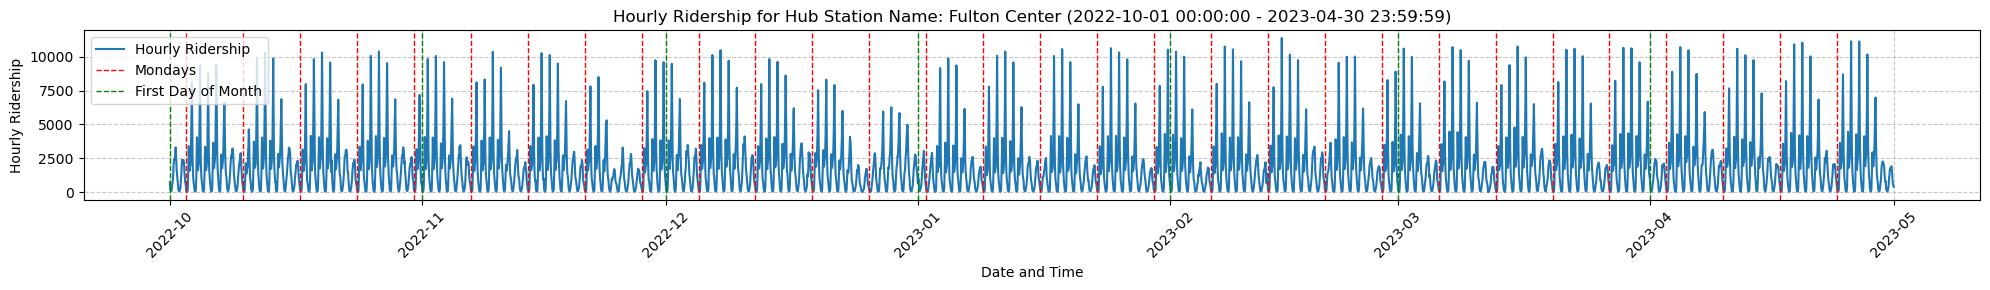

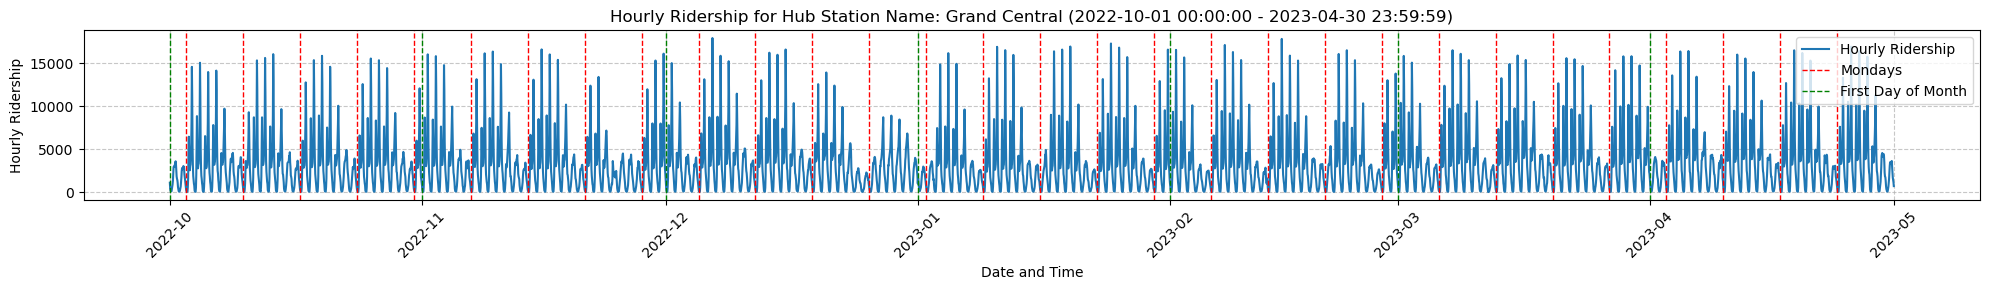

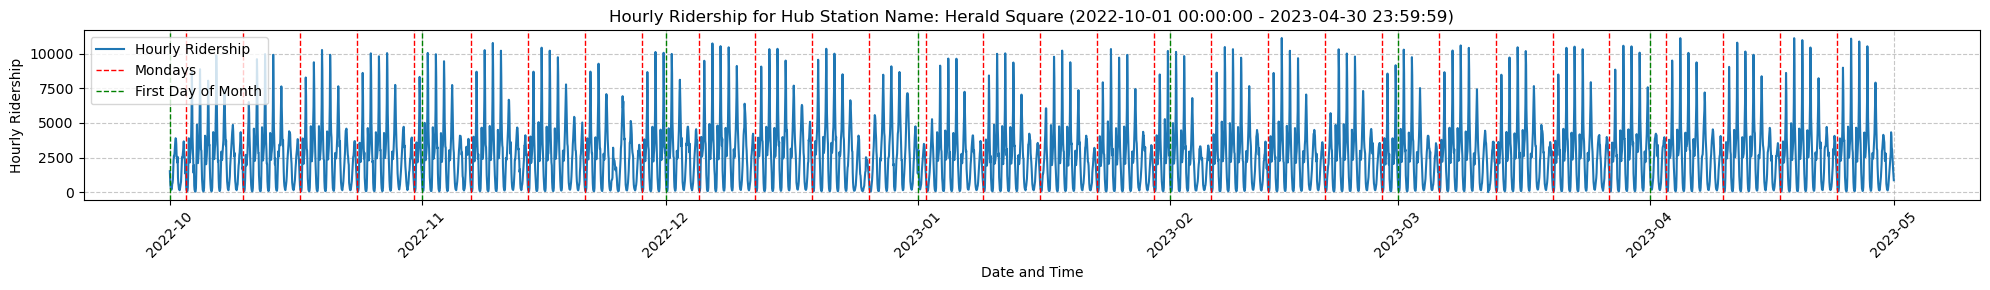

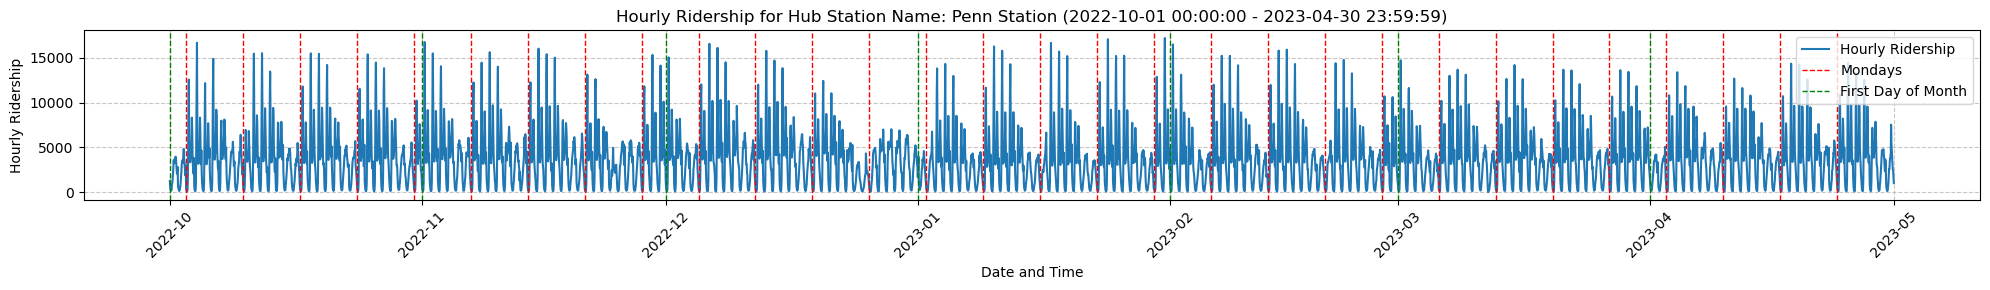

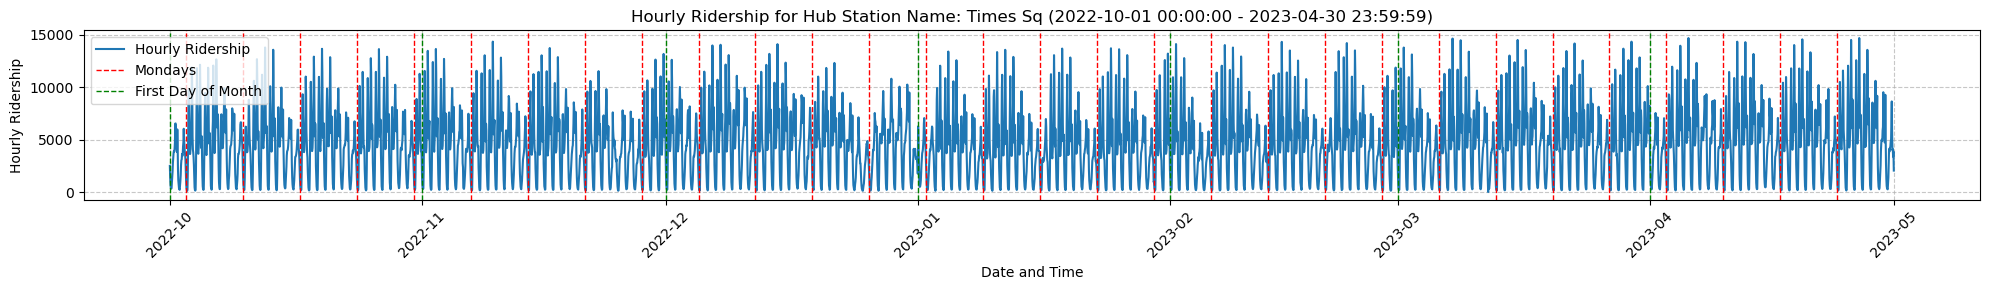

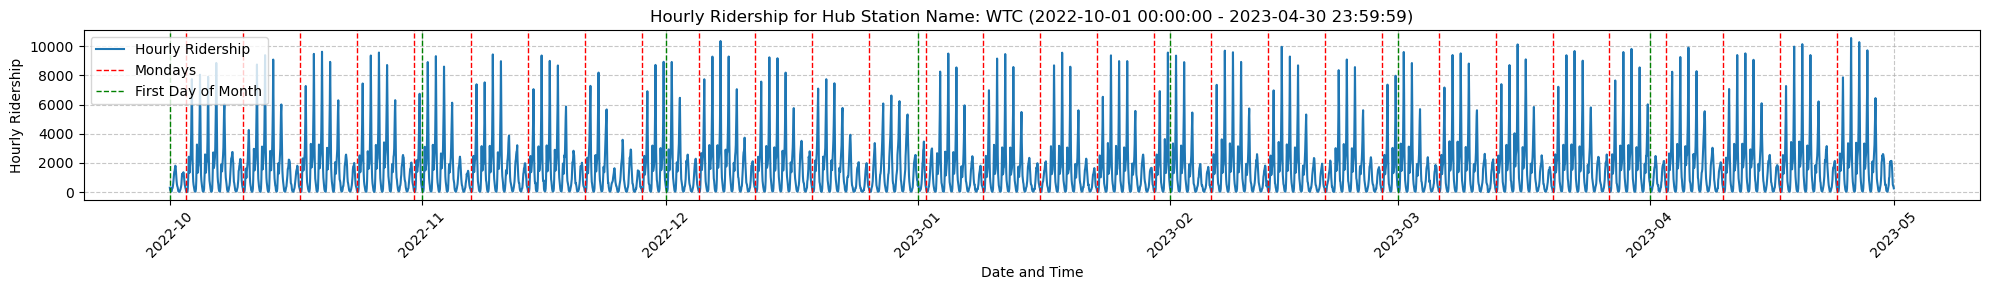

In [ ]:
# Define the time range
start_date = pd.to_datetime('2022-10-01')
end_date = pd.to_datetime('2023-04-30 23:59:59')

# Get all Mondays within the date range
mondays = pd.date_range(start=start_date, end=end_date, freq='W-MON')

# Get the first day of each month within the date range
first_days_of_month = pd.date_range(start=start_date.to_period('M').start_time, end=end_date.to_period('M').end_time, freq='MS')

for hub_name, df_station in separated_dfs.items():
    df_station = df_station.reset_index()
    # Create a mask specific to the current df_station to avoid reindexing warning
    local_mask = (df_station['transit_timestamp'] >= start_date) & (df_station['transit_timestamp'] <= end_date)
    df_filtered = df_station[local_mask].sort_values(by='transit_timestamp')

    plt.figure(figsize=(20, 3))
    sns.lineplot(
        data=df_filtered,
        x='transit_timestamp',
        y='ridership',
        label='Hourly Ridership' # Added label for the line plot
    )

    # Add vertical lines for Mondays
    for i, monday in enumerate(mondays):
        plt.axvline(x=monday, color='red', linestyle='--', linewidth=1, label='Mondays' if i == 0 else "")

    # Add vertical lines for the first day of each month
    for i, first_day in enumerate(first_days_of_month):
        plt.axvline(x=first_day, color='green', linestyle='--', linewidth=1, label='First Day of Month' if i == 0 else "")

    plt.title(f'Hourly Ridership for Hub Station Name: {hub_name} ({start_date} - {end_date})')
    plt.xlabel('Date and Time')
    plt.ylabel('Hourly Ridership')
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.legend()
    plt.show()

### Chronological Train-test split

Each station's time series is split chronologically into an 80% training set and a 20% test set. Because subway ridership has an inherent temporal structure, random shuffling would result in data leakage where future observations are seen during training.

The time ranges and shapes of each split are printed for verification.

In [ ]:
train_test_splits = {}

for hub_name, df_station in separated_dfs.items():
    # Ensure the dataframe is sorted by its index (transit_timestamp)
    df_sorted = df_station.sort_index()

    # Calculate the split point for 80% training and 20% testing
    split_point = int(len(df_sorted) * 0.8)

    # Perform the chronological train-test split
    train_df = df_sorted.iloc[:split_point]
    test_df = df_sorted.iloc[split_point:]

    train_test_splits[hub_name] = {'train': train_df, 'test': test_df}

    print(f"\n--- {hub_name} ---")
    print(f"Train set shape: {train_df.shape}")
    print(f"Train set time range: {train_df.index.min()} to {train_df.index.max()}")
    print(f"Test set shape: {test_df.shape}")
    print(f"Test set time range: {test_df.index.min()} to {test_df.index.max()}")


--- Fulton Center ---
Train set shape: (14112, 1)
Train set time range: 2022-05-16 09:00:00 to 2023-12-25 08:00:00
Test set shape: (3528, 1)
Test set time range: 2023-12-25 09:00:00 to 2024-05-20 08:00:00

--- Grand Central ---
Train set shape: (14112, 1)
Train set time range: 2022-05-16 09:00:00 to 2023-12-25 08:00:00
Test set shape: (3528, 1)
Test set time range: 2023-12-25 09:00:00 to 2024-05-20 08:00:00

--- Herald Square ---
Train set shape: (14112, 1)
Train set time range: 2022-05-16 09:00:00 to 2023-12-25 08:00:00
Test set shape: (3528, 1)
Test set time range: 2023-12-25 09:00:00 to 2024-05-20 08:00:00

--- Penn Station ---
Train set shape: (14112, 1)
Train set time range: 2022-05-16 09:00:00 to 2023-12-25 08:00:00
Test set shape: (3528, 1)
Test set time range: 2023-12-25 09:00:00 to 2024-05-20 08:00:00

--- Times Sq ---
Train set shape: (14112, 1)
Train set time range: 2022-05-16 09:00:00 to 2023-12-25 08:00:00
Test set shape: (3528, 1)
Test set time range: 2023-12-25 09:00:00

## Prophet Hyperparameter Tuning

This section implements a grid search over Prophet's Fourier-order hyperparameters for daily, weekly, and yearly seasonality (values: 10, 15, 20 for daily/weekly; 5, 10, 15 for yearly). Each candidate configuration is evaluated using Prophet's built-in time-series cross-validation, applied within the training set.

CV parameters:
- `initial='365 days'` (minimum 1 year of history before each cutoff),
- `period='60 days'` (cutoff spacing),
- `horizon='30 days'` (forecast window per fold). This yields ~3–4 folds per station.
The scoring metric is **CV WMAPE** (Weighted Mean Absolute Percentage Error computed across all CV fold predictions), which is robust to near-zero ridership hours. Negative forecasts are clipped to zero before scoring.

After the best hyperparameters were identified, the final model was refit on the full training set with those parameters.

In [ ]:
from prophet.diagnostics import cross_validation

prophet_models = {}
prophet_forecasts = {}
prophet_metrics = {}

hyperparameter_grid = {
    'daily_seasonality': [10, 15, 20],
    'weekly_seasonality': [10, 15, 20],
    'yearly_seasonality': [5, 10, 15]
}

best_models_per_hub = {}
best_metrics_per_hub = {}

# CV is performed entirely within the training set
# initial=365d ensures at least 1 full year of history before the first cutoff.
# period=60d gives ~3-4 cutoffs; horizon=30d is the forecast window evaluated each fold.
cv_initial = '365 days'
cv_period  = '60 days'
cv_horizon = '30 days'

for hub_name in train_test_splits.keys():
    print(f"\n--- Tuning Prophet for {hub_name} ---")

    train_data = train_test_splits[hub_name]['train'].reset_index()

    prophet_train = pd.DataFrame({
        'ds': train_data['transit_timestamp'],
        'y': train_data['ridership']
    })

    best_cv_wmape = float('inf')
    current_best_params = None

    for ds_val in hyperparameter_grid['daily_seasonality']:
        for ws_val in hyperparameter_grid['weekly_seasonality']:
            for ys_val in hyperparameter_grid['yearly_seasonality']:
                print(f"  Trying: daily={ds_val}, weekly={ws_val}, yearly={ys_val}", end='  ')

                m = Prophet(
                    seasonality_mode='multiplicative',
                    daily_seasonality=ds_val,
                    weekly_seasonality=ws_val,
                    yearly_seasonality=ys_val,
                    changepoint_prior_scale=0.05,
                    seasonality_prior_scale=10.0,
                    changepoint_range=0.8
                )
                m.add_country_holidays(country_name='US')
                m.fit(prophet_train)

                df_cv = cross_validation(
                    m,
                    initial=cv_initial,
                    period=cv_period,
                    horizon=cv_horizon,
                    disable_tqdm=True
                )

                # Clip negatives before scoring
                df_cv['yhat'] = np.clip(df_cv['yhat'], a_min=0, a_max=None)

                y_true_cv = df_cv['y'].values
                y_pred_cv = df_cv['yhat'].values

                denom = np.sum(np.abs(y_true_cv))
                cv_wmape = (np.sum(np.abs(y_true_cv - y_pred_cv)) / denom) * 100 if denom > 0 else np.nan

                print(f"CV WMAPE: {cv_wmape:.2f}%")

                if not np.isnan(cv_wmape) and cv_wmape < best_cv_wmape:
                    best_cv_wmape = cv_wmape
                    current_best_params = {
                        'daily_seasonality': ds_val,
                        'weekly_seasonality': ws_val,
                        'yearly_seasonality': ys_val
                    }

    print(f"Best CV WMAPE for {hub_name}: {best_cv_wmape:.2f}% → params: {current_best_params}")

    # Refit the winning configuration on the full training set
    final_model = Prophet(
        seasonality_mode='multiplicative',
        daily_seasonality=current_best_params['daily_seasonality'],
        weekly_seasonality=current_best_params['weekly_seasonality'],
        yearly_seasonality=current_best_params['yearly_seasonality'],
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10.0,
        changepoint_range=0.8
    )
    final_model.add_country_holidays(country_name='US')
    final_model.fit(prophet_train)

    best_models_per_hub[hub_name] = final_model
    best_metrics_per_hub[hub_name] = {
        'CV_WMAPE (%)': best_cv_wmape,
        'params': current_best_params
    }
    prophet_metrics[hub_name] = best_metrics_per_hub[hub_name]

comparison_df = pd.DataFrame({
    hub: {'CV_WMAPE (%)': best_metrics_per_hub[hub]['CV_WMAPE (%)'],
          **best_metrics_per_hub[hub]['params']}
    for hub in best_metrics_per_hub
}).T
print("\nComparison of Best Prophet Configs Across Hubs (CV-based tuning):")
display(comparison_df.round(2))


--- Tuning Prophet for Fulton Center ---
  Trying: daily=10, weekly=10, yearly=5  

05:44:11 - cmdstanpy - INFO - Chain [1] start processing
05:44:12 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
05:44:12 - cmdstanpy - INFO - Chain [1] start processing
05:44:13 - cmdstanpy - INFO - Chain [1] done processing
05:44:14 - cmdstanpy - INFO - Chain [1] start processing
05:44:15 - cmdstanpy - INFO - Chain [1] done processing
05:44:15 - cmdstanpy - INFO - Chain [1] start processing
05:44:16 - cmdstanpy - INFO - Chain [1] done processing
05:44:16 - cmdstanpy - INFO - Chain [1] start processing
05:44:18 - cmdstanpy - INFO - Chain [1] done processing


CV WMAPE: 26.02%
  Trying: daily=10, weekly=10, yearly=10  

05:44:18 - cmdstanpy - INFO - Chain [1] start processing
05:44:20 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
05:44:21 - cmdstanpy - INFO - Chain [1] start processing
05:44:22 - cmdstanpy - INFO - Chain [1] done processing
05:44:22 - cmdstanpy - INFO - Chain [1] start processing
05:44:23 - cmdstanpy - INFO - Chain [1] done processing
05:44:24 - cmdstanpy - INFO - Chain [1] start processing
05:44:25 - cmdstanpy - INFO - Chain [1] done processing
05:44:25 - cmdstanpy - INFO - Chain [1] start processing
05:44:27 - cmdstanpy - INFO - Chain [1] done processing


CV WMAPE: 26.13%
  Trying: daily=10, weekly=10, yearly=15  

...

06:13:42 - cmdstanpy - INFO - Chain [1] start processing
06:13:46 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
06:13:46 - cmdstanpy - INFO - Chain [1] start processing
06:13:49 - cmdstanpy - INFO - Chain [1] done processing
06:13:50 - cmdstanpy - INFO - Chain [1] start processing
06:13:52 - cmdstanpy - INFO - Chain [1] done processing
06:13:52 - cmdstanpy - INFO - Chain [1] start processing
06:13:56 - cmdstanpy - INFO - Chain [1] done processing
06:13:56 - cmdstanpy - INFO - Chain [1] start processing
06:14:00 - cmdstanpy - INFO - Chain [1] done processing


CV WMAPE: 18.85%
Best CV WMAPE for WTC: 18.82% → params: {'daily_seasonality': 20, 'weekly_seasonality': 20, 'yearly_seasonality': 10}


06:14:00 - cmdstanpy - INFO - Chain [1] start processing
06:14:04 - cmdstanpy - INFO - Chain [1] done processing



Comparison of Best Prophet Configs Across Hubs (CV-based tuning):


,CV_WMAPE (%),daily_seasonality,weekly_seasonality,yearly_seasonality
Fulton Center,18.00,15.0,20.0,5.0
Grand Central,18.21,20.0,20.0,10.0
Herald Square,13.56,20.0,20.0,5.0
Penn Station,17.10,10.0,20.0,5.0
Times Sq,12.57,20.0,20.0,5.0
WTC,18.82,20.0,20.0,10.0


The best-performing Prophet model and its metrics for each station are saved using `pickle` module (currently commented out for reuse). The corresponding load cell (active) restores these objects, bypassing the long-time hyperparameter grid search.

In [ ]:
import pickle
import os

# Define a directory to save the models and metrics
save_dir = 'prophet_models_and_metrics'
os.makedirs(save_dir, exist_ok=True)

print(f"Saving models and metrics to '{save_dir}'...")

# Save best models
for hub_name, model in best_models_per_hub.items():
    model_filename = os.path.join(save_dir, f'{hub_name.replace(" ", "_")}_prophet_model.pkl')
    with open(model_filename, 'wb') as f:
        pickle.dump(model, f)
    print(f"  Saved model for {hub_name} to {model_filename}")

# Save best metrics
metrics_filename = os.path.join(save_dir, 'best_prophet_metrics.pkl')
with open(metrics_filename, 'wb') as f:
    pickle.dump(best_metrics_per_hub, f)
print(f"  Saved best metrics to {metrics_filename}")

print("\nAll models and metrics saved successfully!")

Saving models and metrics to 'prophet_models_and_metrics'...
  Saved model for Fulton Center to prophet_models_and_metrics/Fulton_Center_prophet_model.pkl
  Saved model for Grand Central to prophet_models_and_metrics/Grand_Central_prophet_model.pkl
  Saved model for Herald Square to prophet_models_and_metrics/Herald_Square_prophet_model.pkl
  Saved model for Penn Station to prophet_models_and_metrics/Penn_Station_prophet_model.pkl
  Saved model for Times Sq to prophet_models_and_metrics/Times_Sq_prophet_model.pkl
  Saved model for WTC to prophet_models_and_metrics/WTC_prophet_model.pkl
  Saved best metrics to prophet_models_and_metrics/best_prophet_metrics.pkl

All models and metrics saved successfully!


In [ ]:
import pickle
import os

# Define the directory where models and metrics are saved
save_dir = 'prophet_models_and_metrics'

# Load the models and metrics
loaded_models = {}
loaded_metrics = {}
for hub_name in train_test_splits.keys():
    model_filename = os.path.join(save_dir, f'{hub_name.replace(" ", "_")}_prophet_model.pkl')
    if os.path.exists(model_filename):
        with open(model_filename, 'rb') as f:
            loaded_models[hub_name] = pickle.load(f)
        print(f"Loaded model for {hub_name}")
    else:
        print(f"Model file not found for {hub_name}: {model_filename}")

metrics_filename = os.path.join(save_dir, 'best_prophet_metrics.pkl')
if os.path.exists(metrics_filename):
    with open(metrics_filename, 'rb') as f:
        loaded_metrics = pickle.load(f)
    print(f"Loaded best metrics")
else:
    print(f"Metrics file not found: {metrics_filename}")

Loaded model for Fulton Center
Loaded model for Grand Central
Loaded model for Herald Square
Loaded model for Penn Station
Loaded model for Times Sq
Loaded model for WTC
Loaded best metrics


## Final Performance on Test Set

The CV WMAPE from tuning is placed side-by-side with the test set MAE, RMSE, and WMAPE in a single comparison table. This comparison serves as a sanity check on the reliability of the 80/20 split.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

test_metrics = {}

for hub_name in loaded_models.keys():
    model = loaded_models[hub_name]
    test_df = train_test_splits[hub_name]['test'].reset_index()

    # Prepare test data for prediction
    prophet_test_data = pd.DataFrame({
        'ds': test_df['transit_timestamp']
    })

    # Predict
    forecast = model.predict(prophet_test_data)

    # Extract actual and predicted values
    y_true = test_df['ridership'].values
    y_pred = forecast['yhat'].values

    # Clip negative predictions to 0
    y_pred = np.clip(y_pred, a_min=0, a_max=None)

    # Compute metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.sum(np.abs(y_true))
    wmape = (np.sum(np.abs(y_true - y_pred)) / denom) * 100 if denom > 0 else np.nan

    test_metrics[hub_name] = {
        'MAE': mae,
        'RMSE': rmse,
        'WMAPE (%)': wmape
    }

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    hub: {
        'CV_WMAPE (%)': loaded_metrics[hub]['CV_WMAPE (%)'],
        'Test_MAE': test_metrics[hub]['MAE'],
        'Test_RMSE': test_metrics[hub]['RMSE'],
        'Test_WMAPE (%)': test_metrics[hub]['WMAPE (%)']
    }
    for hub in loaded_models.keys()
}).T

print("Comparison of CV Metrics vs. Test Set Metrics:")
display(comparison_df.round(2))

Comparison of CV Metrics vs. Test Set Metrics:


,CV_WMAPE (%),Test_MAE,Test_RMSE,Test_WMAPE (%)
Fulton Center,18.00,417.36,664.63,19.95
Grand Central,18.21,745.32,1136.09,20.09
Herald Square,13.56,585.47,817.42,21.45
Penn Station,17.10,708.44,1044.84,18.46
Times Sq,12.57,757.19,1051.80,14.93
WTC,18.82,414.02,643.30,22.20


## Prophet Forecasted vs. Actual Ridership

The loaded Prophet models generate forecasts over each station's held-out test period. The actual vs. predicted ridership are overlaid on a time-series plot per station, enabling visual check of how well the model captures weekly cycles, peak magnitude, and trend. Negative forecasts are clipped to zero before plotting.

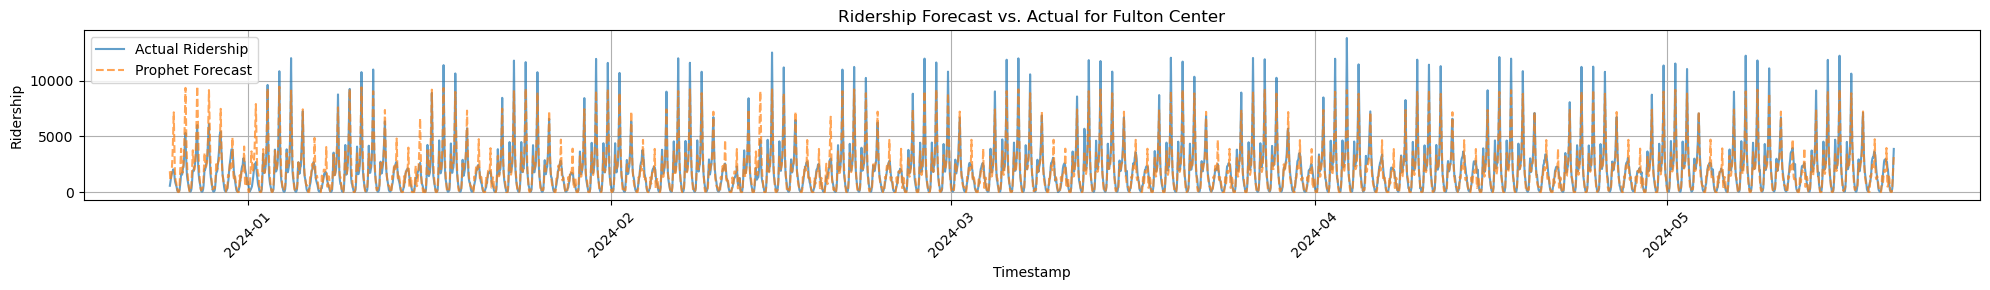

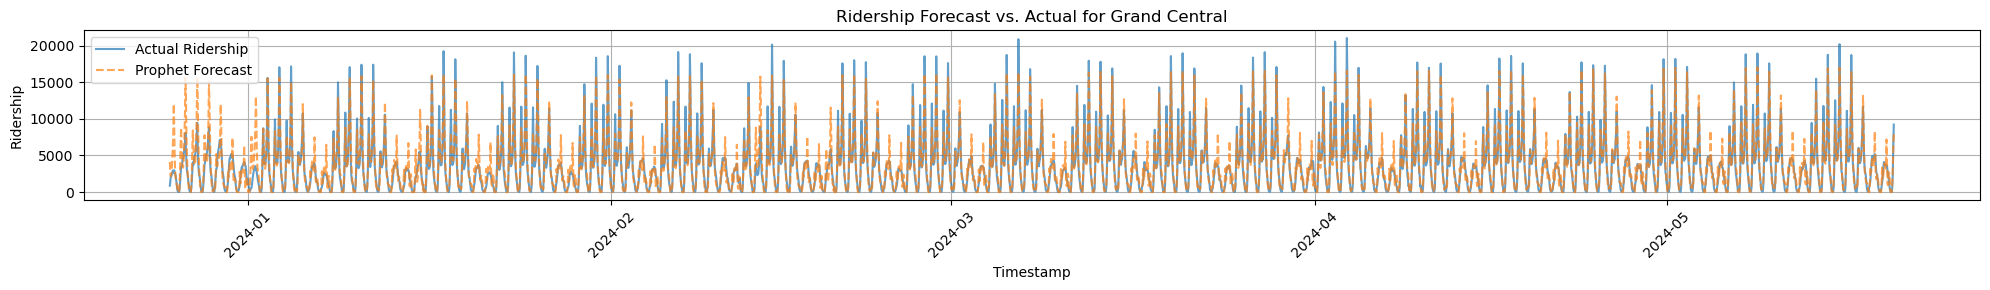

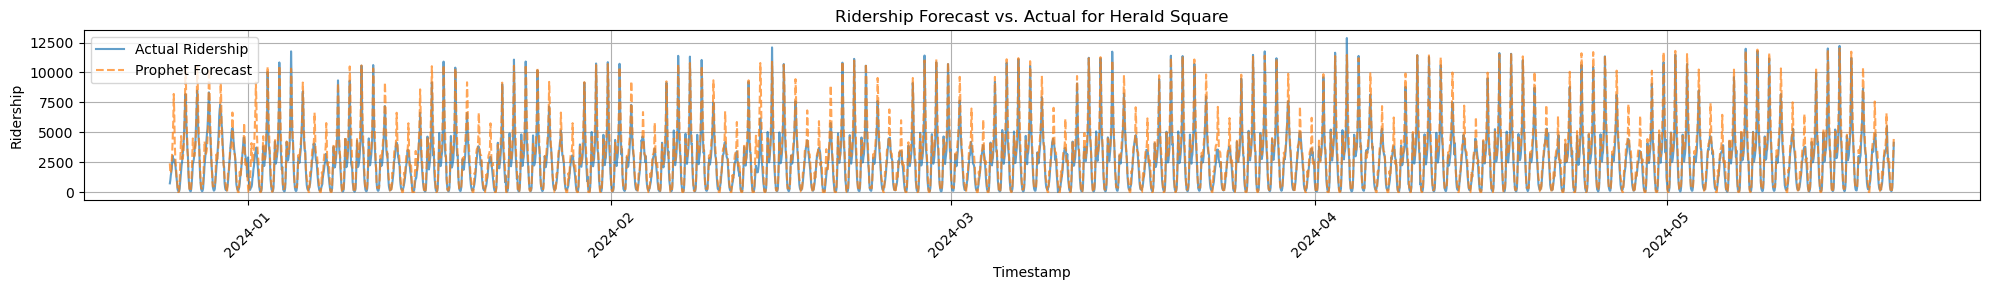

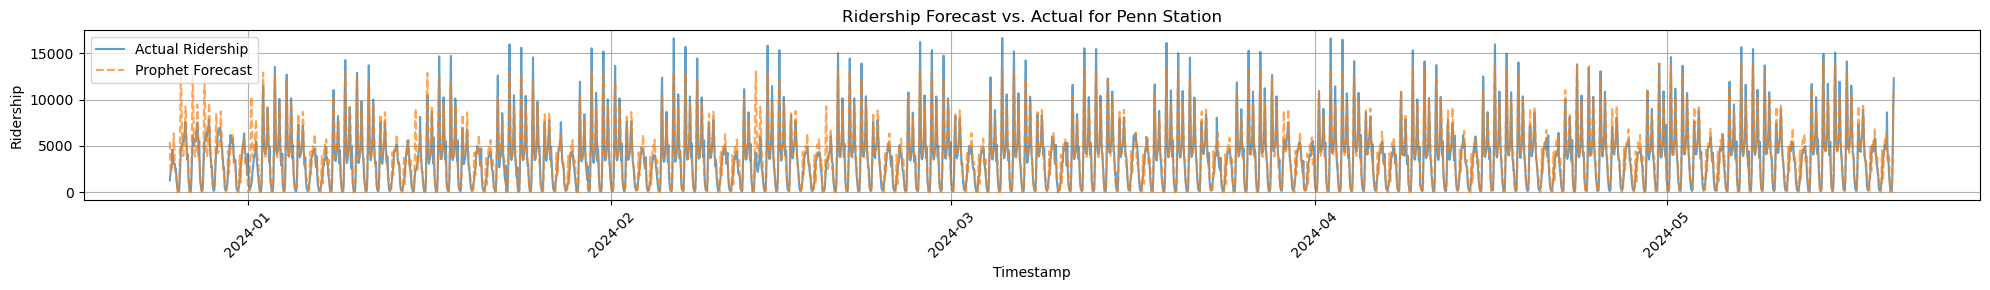

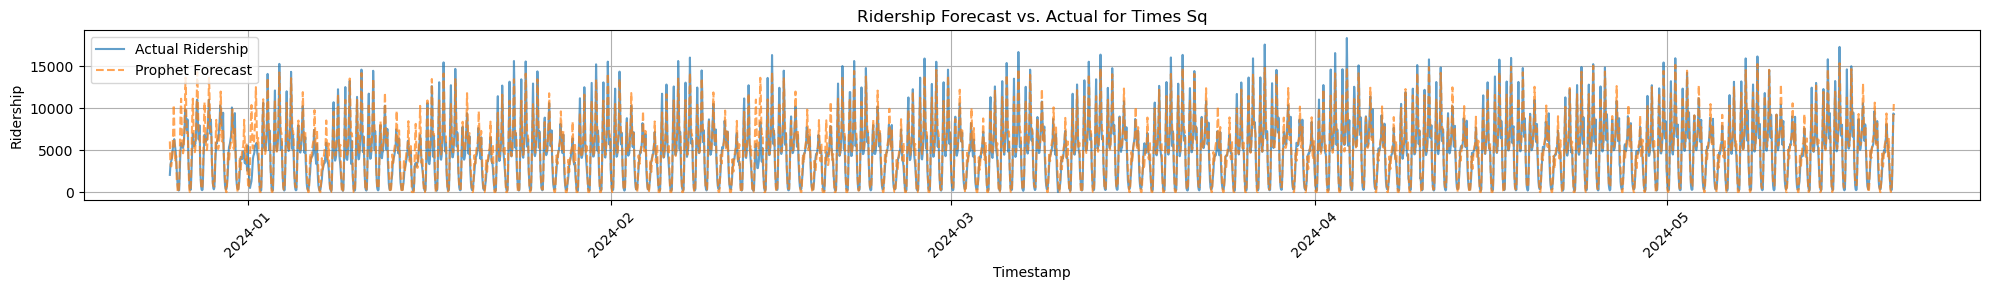

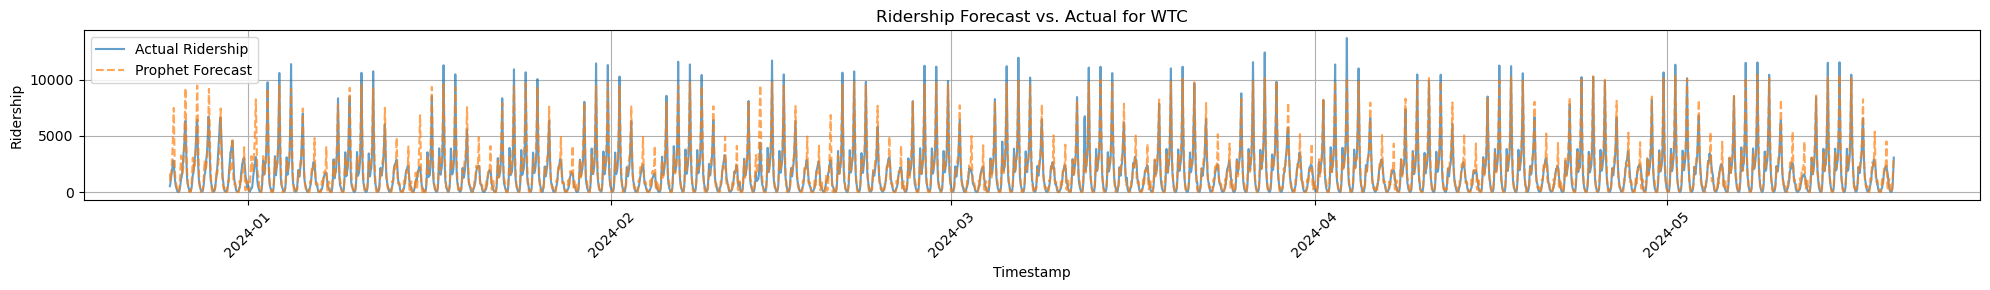

In [ ]:
for hub_name in loaded_models.keys():
    model = loaded_models[hub_name]
    test_df = train_test_splits[hub_name]['test'].reset_index()

    # Prepare test data for prediction
    prophet_test_data = pd.DataFrame({
        'ds': test_df['transit_timestamp']
    })

    # Predict
    forecast = model.predict(prophet_test_data)

    # Extract actual and predicted values
    y_true = test_df['ridership'].values
    y_pred = forecast['yhat'].values

    # Clip negative predictions to 0
    y_pred = np.clip(y_pred, a_min=0, a_max=None)

    plt.figure(figsize=(20, 3))
    plt.plot(test_df['transit_timestamp'], y_true, label='Actual Ridership', alpha=0.7)
    plt.plot(test_df['transit_timestamp'], y_pred, label='Prophet Forecast', linestyle='--', alpha=0.7)
    plt.title(f'Ridership Forecast vs. Actual for {hub_name}')
    plt.xlabel('Timestamp')
    plt.ylabel('Ridership')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Residual Analysis

Forecasting residuals are computed and examined through three diagnostic plots per station:

- a histogram with KDE to check for approximate normality and any systematic bias;
- a scatter plot of residuals over time to detect heteroskedasticity or structural drift in forecast error;
- a scatter plot of residuals versus predicted values to identify any non-linear patterns the model failed to capture.


--- Residual Analysis for Fulton Center ---


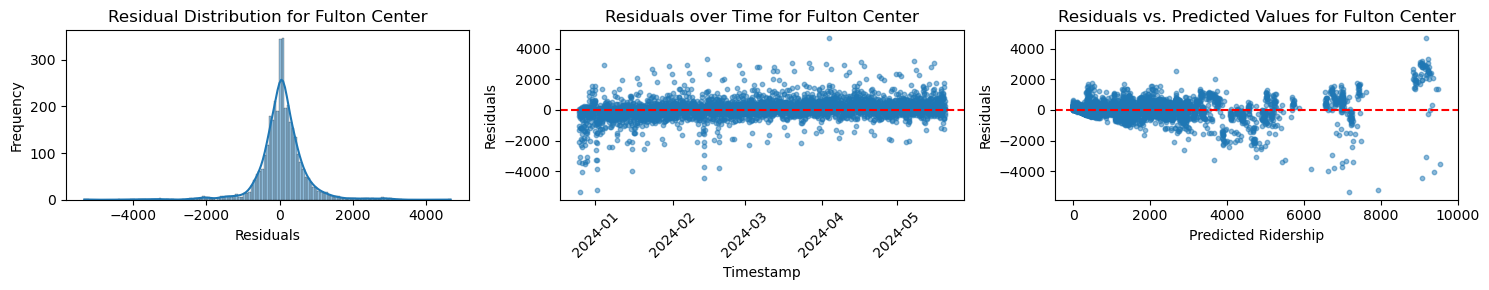


--- Residual Analysis for Grand Central ---


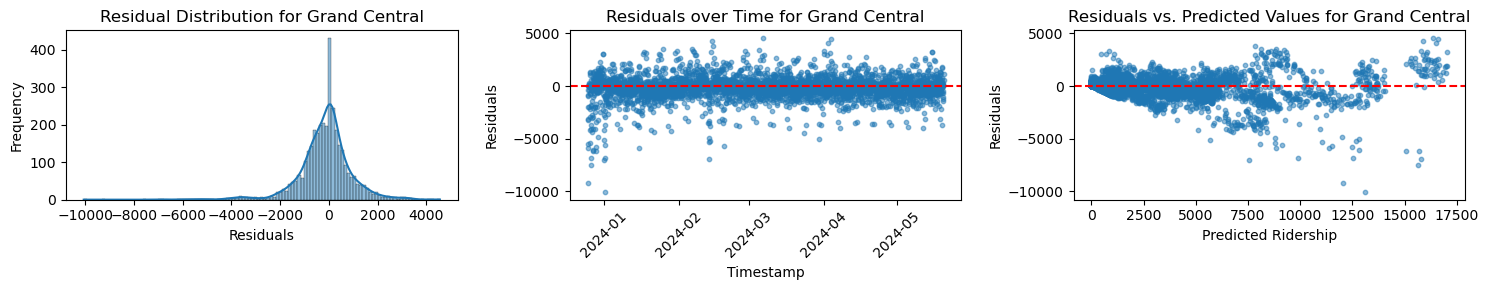


--- Residual Analysis for Herald Square ---


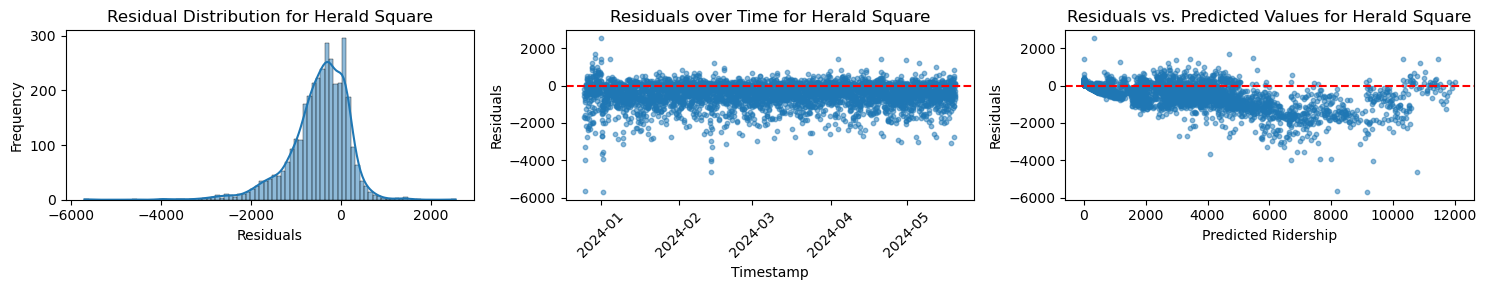


--- Residual Analysis for Penn Station ---


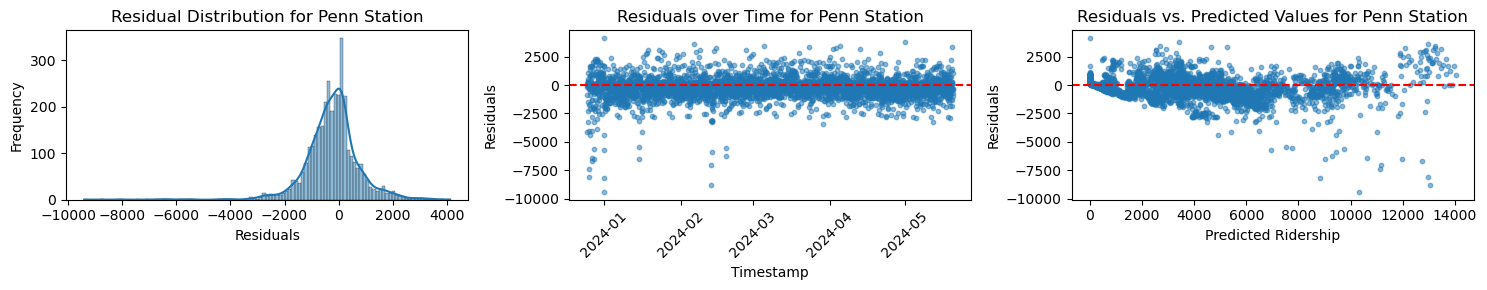


--- Residual Analysis for Times Sq ---


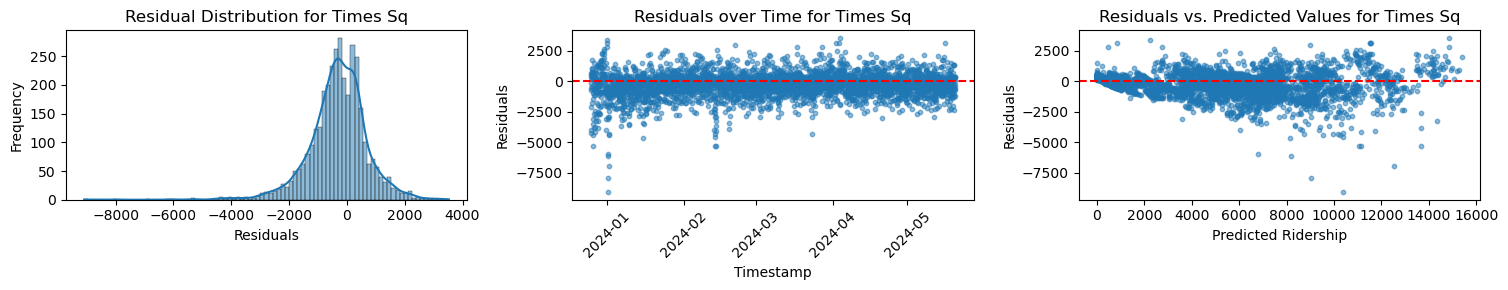


--- Residual Analysis for WTC ---


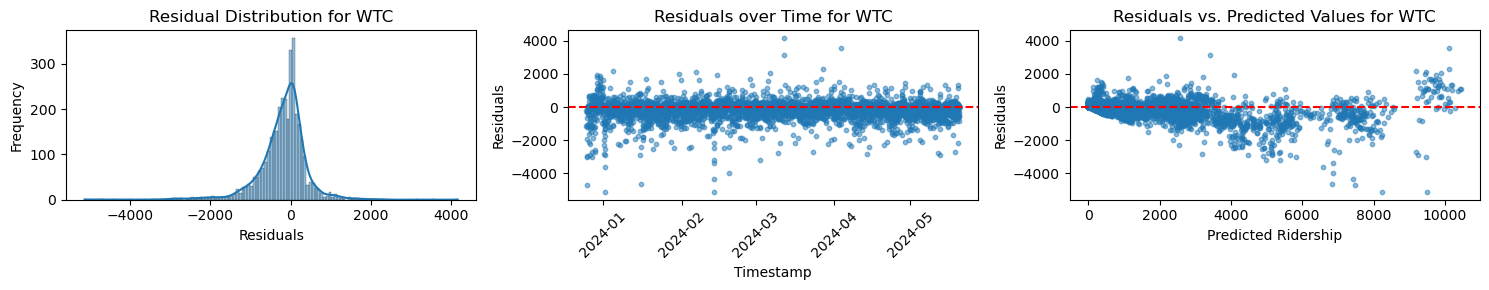

In [ ]:
for hub_name in loaded_models.keys():
    model = loaded_models[hub_name]
    test_df = train_test_splits[hub_name]['test'].reset_index()

    # Prepare test data for prediction
    prophet_test_data = pd.DataFrame({
        'ds': test_df['transit_timestamp']
    })

    # Predict
    forecast = model.predict(prophet_test_data)

    # Extract actual and predicted values
    y_true = test_df['ridership'].values
    y_pred = forecast['yhat'].values

    # Clip negative predictions to 0
    y_pred = np.clip(y_pred, a_min=0, a_max=None)

    # Calculate residuals
    residuals = y_true - y_pred

    print(f"\n--- Residual Analysis for {hub_name} ---")

    # Plot 1: Histogram of Residuals
    plt.figure(figsize=(15, 3))
    plt.subplot(1, 3, 1)
    sns.histplot(residuals, kde=True)
    plt.title(f'Residual Distribution for {hub_name}')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')

    # Plot 2: Residuals vs. Time
    plt.subplot(1, 3, 2)
    plt.scatter(test_df['transit_timestamp'], residuals, alpha=0.5, s=10)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Residuals over Time for {hub_name}')
    plt.xlabel('Timestamp')
    plt.ylabel('Residuals')
    plt.xticks(rotation=45)

    # Plot 3: Residuals vs. Predicted Values
    plt.subplot(1, 3, 3)
    plt.scatter(y_pred, residuals, alpha=0.5, s=10)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Residuals vs. Predicted Values for {hub_name}')
    plt.xlabel('Predicted Ridership')
    plt.ylabel('Residuals')

    plt.tight_layout()
    plt.show()

## Prophet Component Decomposition

For each hub, `plot_components` decomposes the forecast into its individual learned signals: overall trend, US holiday effects, weekly seasonality (day-of-week profile), yearly seasonality (annual cycle), and daily seasonality (hour-of-day profile). A future dataframe spanning train + test is used so all components are visible over the full data range.

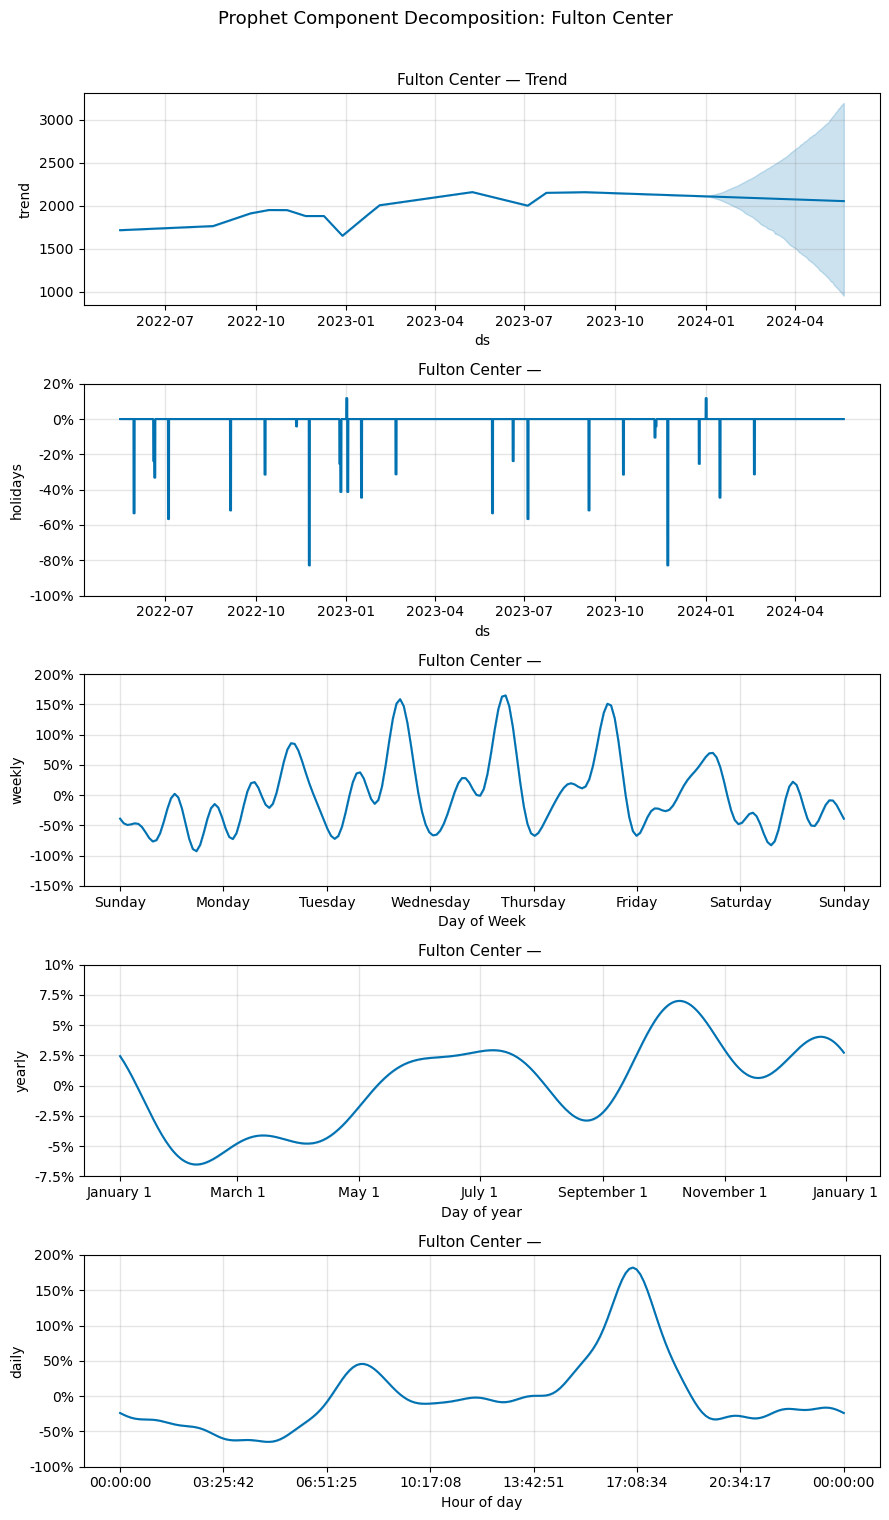

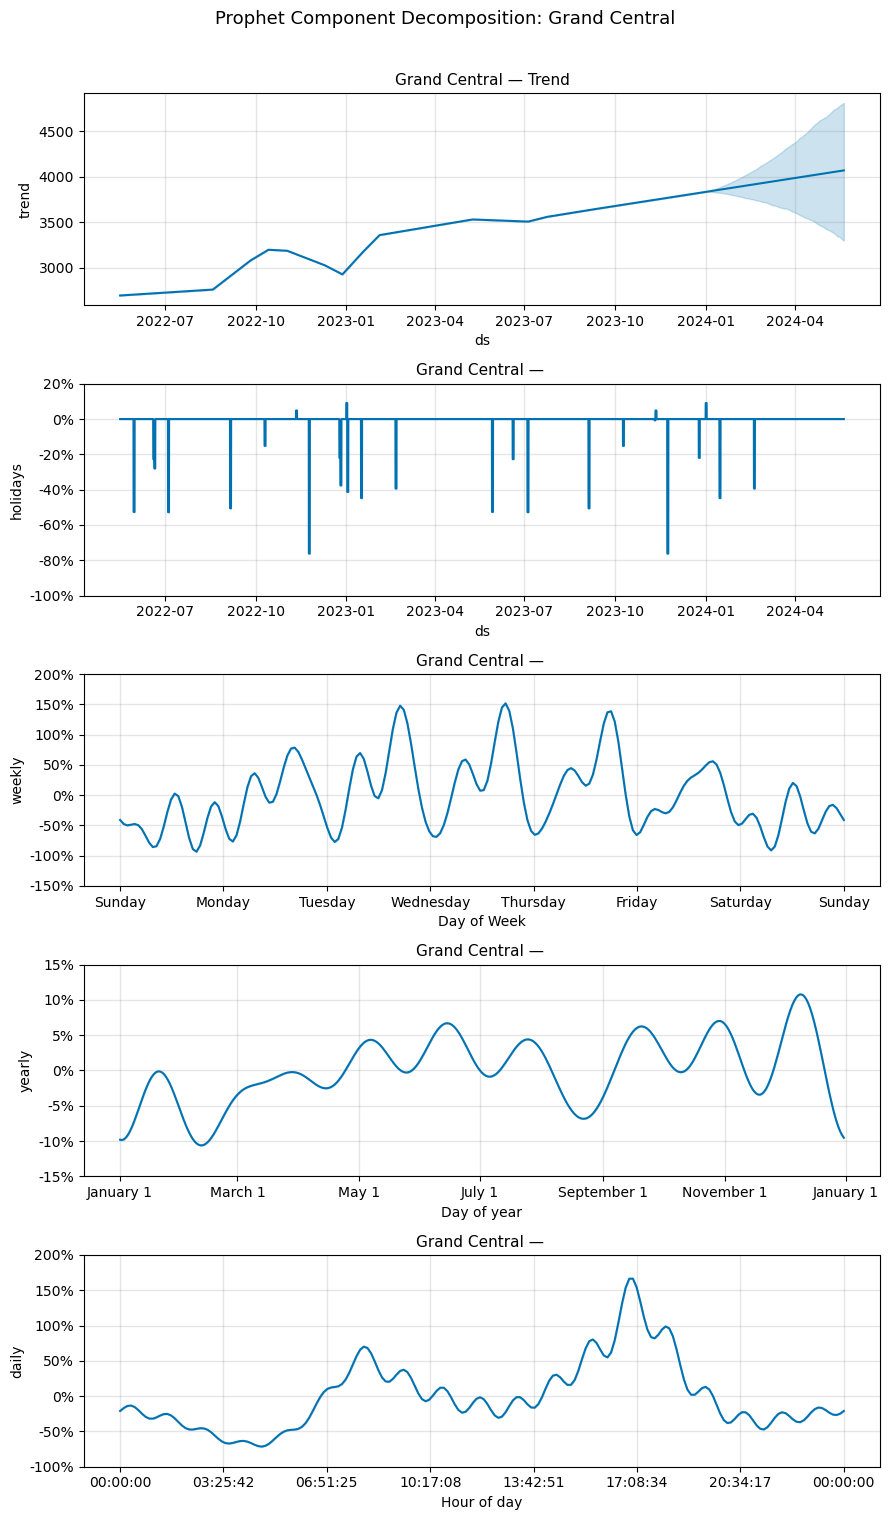

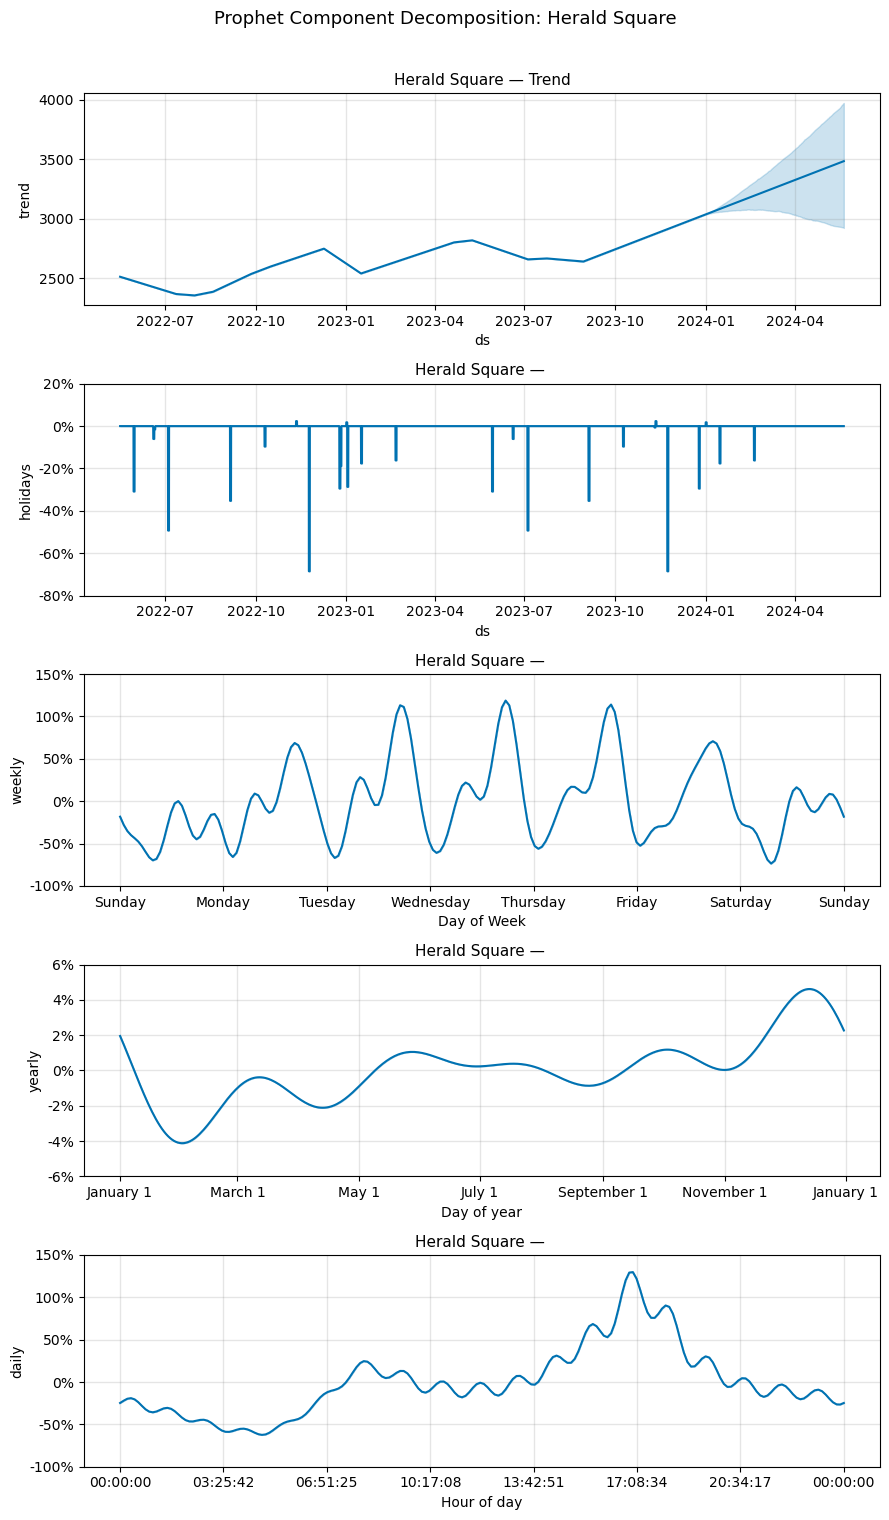

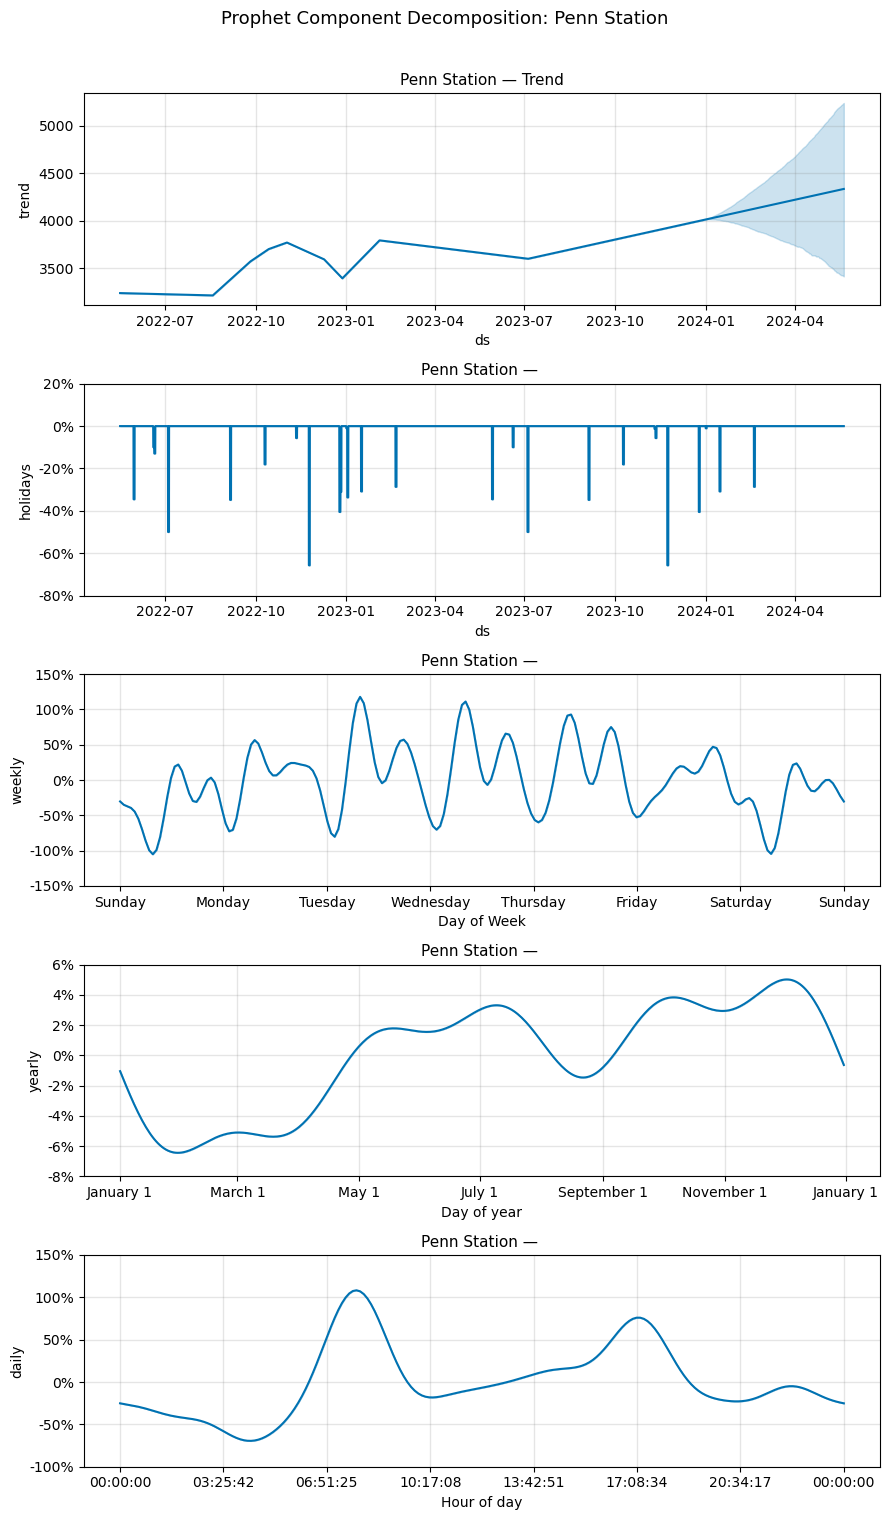

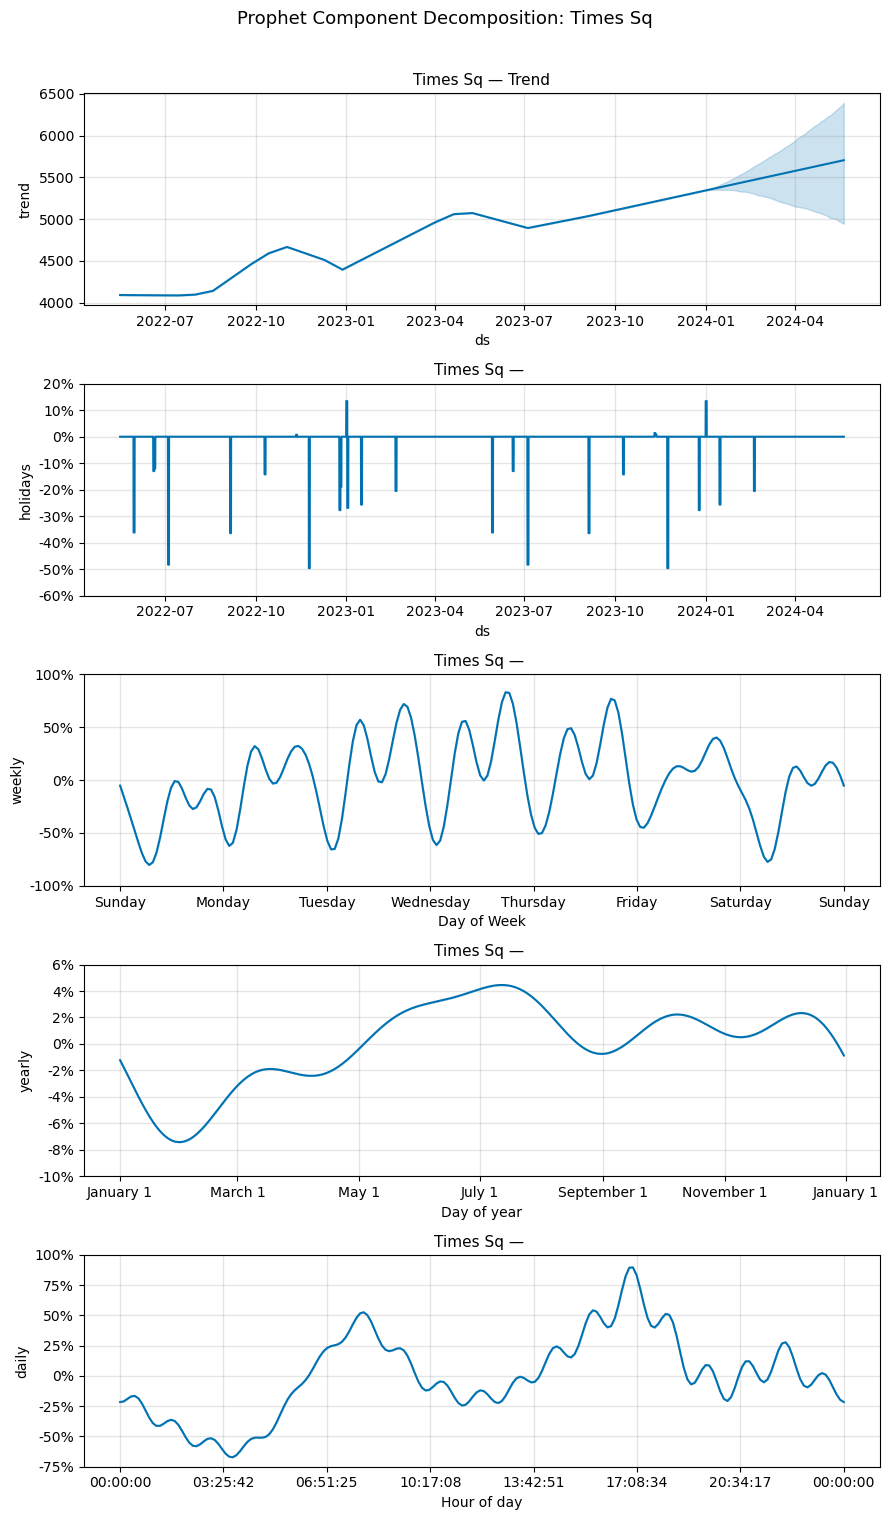

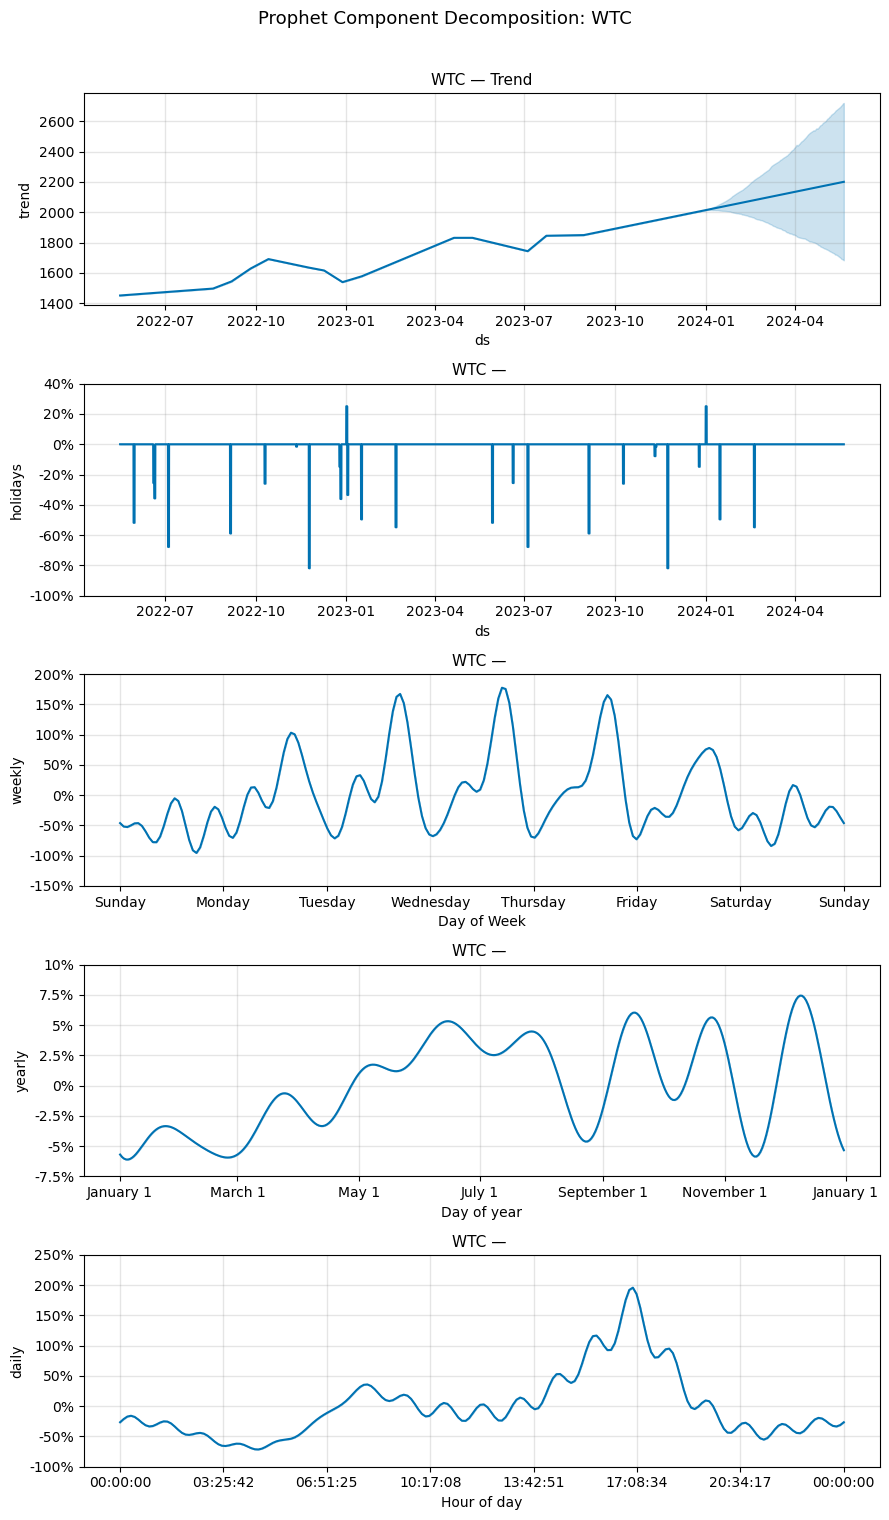

In [ ]:
for hub_name in best_models_per_hub.keys():
    model = best_models_per_hub[hub_name]

    # Extend to cover the full train + test span so components are shown end-to-end
    n_test = len(train_test_splits[hub_name]['test'])
    future = model.make_future_dataframe(periods=n_test, freq='h')
    forecast = model.predict(future)

    fig = model.plot_components(forecast)

    # Label each subplot with the hub name
    axes = fig.get_axes()
    axes[0].set_title(f'{hub_name} — Trend', fontsize=11)
    for ax in axes[1:]:
        current_title = ax.get_title()
        ax.set_title(f'{hub_name} — {current_title}', fontsize=11)

    fig.suptitle(f'Prophet Component Decomposition: {hub_name}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()